In [2]:
import os, sys

REPO_ROOT    = os.path.dirname(os.getcwd())
DATA_DIR     = os.path.join(REPO_ROOT, 'data')
AVA_DIR      = os.path.join(DATA_DIR, 'AVA_Files')
AVA_TXT      = os.path.join(AVA_DIR, 'AVA.txt')
TAGS_TXT     = os.path.join(AVA_DIR, 'tags.txt')
NETFLIX_CSV  = os.path.join(DATA_DIR, 'netflix_titles.csv')
AD_CLICK_CSV = os.path.join(REPO_ROOT, 'notebooks', 'Ad_click_prediction_train (1).csv')
FIGURES_DIR  = os.path.join(REPO_ROOT, 'figures')
OUTPUTS_DIR  = os.path.join(REPO_ROOT, 'outputs')

for d in [DATA_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'REPO_ROOT    : {REPO_ROOT}')
print(f'AVA_TXT      : exists={os.path.exists(AVA_TXT)}')
print(f'NETFLIX_CSV  : exists={os.path.exists(NETFLIX_CSV)}')
print(f'AD_CLICK_CSV : exists={os.path.exists(AD_CLICK_CSV)}')

REPO_ROOT    : /Users/animisha/Documents/ml-netflix-artwork-optimization-poc
AVA_TXT      : exists=True
NETFLIX_CSV  : exists=True
AD_CLICK_CSV : exists=True


In [3]:
import pandas as pd
import numpy as np

cols = ['index','image_id',
        'vote_1','vote_2','vote_3','vote_4','vote_5',
        'vote_6','vote_7','vote_8','vote_9','vote_10',
        'tag_1','tag_2','challenge_id']

ava = pd.read_csv(AVA_TXT, sep=' ', header=None, names=cols)
print(f'AVA shape: {ava.shape}')
print(ava.head(3))

AVA shape: (255530, 15)
   index  image_id  vote_1  vote_2  vote_3  vote_4  vote_5  vote_6  vote_7  \
0      1    953619       0       1       5      17      38      36      15   
1      2    953958      10       7      15      26      26      21      10   
2      3    954184       0       0       4       8      41      56      10   

   vote_8  vote_9  vote_10  tag_1  tag_2  challenge_id  
0       6       5        1      1     22          1396  
1       8       1        2      1     21          1396  
2       3       4        0      0      0          1396  


In [4]:
tag_map = {}
with open(TAGS_TXT, 'r') as f:
    for line in f:
        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            tag_map[int(parts[0])] = parts[1]

ava['tag_1_name'] = ava['tag_1'].map(tag_map).fillna('none')
ava['tag_2_name'] = ava['tag_2'].map(tag_map).fillna('none')

print('Tag 1 distribution:')
print(ava['tag_1_name'].value_counts().head(10))

Tag 1 distribution:
tag_1_name
none               58569
Nature             20827
Landscape          18840
Abstract           17851
Still Life         13843
Portraiture        11140
Emotive             9853
Humorous            9505
Animals             9108
Black and White     8293
Name: count, dtype: int64


In [5]:
vote_cols   = [f'vote_{i}' for i in range(1, 11)]
ratings     = np.arange(1, 11)
vote_matrix = ava[vote_cols].values
total_votes = vote_matrix.sum(axis=1)

ava['mean_score']   = (vote_matrix * ratings).sum(axis=1) / total_votes
ava['total_votes']  = total_votes
weighted_sq         = (vote_matrix * (ratings ** 2)).sum(axis=1) / total_votes
ava['score_std']    = np.sqrt(weighted_sq - ava['mean_score'] ** 2)
ava['high_quality'] = (ava['mean_score'] >= 5.0).astype(int)

ava_sample = ava.sample(n=50000, random_state=42).reset_index(drop=True)

print(f'mean_score range : {ava_sample["mean_score"].min():.2f} - {ava_sample["mean_score"].max():.2f}')
print(f'high_quality rate: {ava_sample["high_quality"].mean()*100:.1f}%')
print(f'columns          : {list(ava_sample.columns)}')

mean_score range : 2.00 - 8.24
high_quality rate: 71.2%
columns          : ['index', 'image_id', 'vote_1', 'vote_2', 'vote_3', 'vote_4', 'vote_5', 'vote_6', 'vote_7', 'vote_8', 'vote_9', 'vote_10', 'tag_1', 'tag_2', 'challenge_id', 'tag_1_name', 'tag_2_name', 'mean_score', 'total_votes', 'score_std', 'high_quality']


In [6]:
tag_to_genre = {
    'Portraiture':'Dramas','Emotive':'Dramas','Candid':'Dramas',
    'Performance':'Dramas','Self Portrait':'Dramas','Maternity':'Dramas',
    'Street':'Dramas','Music':'Dramas','Persuasive':'Dramas',
    'Sports':'Action & Adventure','Action':'Action & Adventure',
    'Landscape':'Action & Adventure','Nature':'Action & Adventure',
    'Travel':'Action & Adventure','Water':'Action & Adventure',
    'Seascapes':'Action & Adventure','Sky':'Action & Adventure',
    'Rural':'Action & Adventure','Panoramic':'Action & Adventure',
    'Transportation':'Action & Adventure','High Dynamic Range (HDR)':'Action & Adventure',
    'Cityscape':'Documentaries','Architecture':'Documentaries',
    'Urban':'Documentaries','Photojournalism':'Documentaries',
    'Political':'Documentaries','Science and Technology':'Documentaries',
    'Astrophotography':'Documentaries','History':'Documentaries','Interior':'Documentaries',
    'Humorous':'Comedies','Snapshot':'Comedies','Food and Drink':'Comedies',
    'Advertisement':'Comedies','Camera Phones':'Comedies',
    'Family':'Children & Family Movies','Animals':'Children & Family Movies',
    'Children':'Children & Family Movies','Birds':'Children & Family Movies',
    'Insects, etc':'Children & Family Movies',
    'Fashion':'Romantic Movies','Floral':'Romantic Movies','Wedding':'Romantic Movies',
    'Black and White':'International Movies','Vintage':'International Movies',
    'Traditional Art':'International Movies','Nude':'International Movies',
    'Analog':'International Movies','Photo-Impressionism':'International Movies',
    'Military':'Thrillers','Horror':'Thrillers',
    'Abstract':'Independent Movies','Still Life':'Independent Movies',
    'Macro':'Independent Movies','Digital Art':'Independent Movies',
    'Studio':'Independent Movies','Infrared':'Independent Movies',
    'Textures':'Independent Movies','Blur':'Independent Movies',
    'Diptych / Triptych':'Independent Movies','Pinhole/Zone Plate':'Independent Movies',
    'Lensbaby':'Independent Movies','Fish Eye':'Independent Movies',
    'Overlays':'Independent Movies','Texture Library':'Independent Movies',
    'none':'Other','DPChallenge GTGs':'Other',
}

def assign_genre(row):
    g = tag_to_genre.get(row['tag_1_name'])
    return g if g else tag_to_genre.get(row['tag_2_name'], 'Other')

ava_sample['netflix_genre'] = ava_sample.apply(assign_genre, axis=1)
print(ava_sample['netflix_genre'].value_counts())

netflix_genre
Action & Adventure          11537
Other                       11452
Independent Movies           8224
Dramas                       5492
Documentaries                4148
Comedies                     3018
Children & Family Movies     2916
International Movies         2179
Romantic Movies               982
Thrillers                      52
Name: count, dtype: int64


In [7]:
ava_genre_stats = ava_sample.groupby('netflix_genre').agg(
    avg_aesthetic_score=('mean_score', 'mean'),
    score_std=('score_std', 'mean'),
    high_quality_rate=('high_quality', 'mean'),
    sample_count=('image_id', 'count')
).reset_index().round(3)

print(ava_genre_stats.to_string(index=False))

           netflix_genre  avg_aesthetic_score  score_std  high_quality_rate  sample_count
      Action & Adventure                5.498      1.395              0.753         11537
Children & Family Movies                5.380      1.411              0.710          2916
                Comedies                5.241      1.478              0.634          3018
           Documentaries                5.408      1.407              0.723          4148
                  Dramas                5.465      1.440              0.749          5492
      Independent Movies                5.341      1.461              0.694          8224
    International Movies                5.472      1.444              0.778          2179
                   Other                5.282      1.438              0.667         11452
         Romantic Movies                5.391      1.406              0.742           982
               Thrillers                5.332      1.418              0.673            52


In [8]:
df_netflix = pd.read_csv(NETFLIX_CSV)

df_netflix['is_movie']       = (df_netflix['type'] == 'Movie').astype(int)
df_netflix['release_decade'] = (df_netflix['release_year'] // 10 * 10)
df_netflix['is_us']          = df_netflix['country'].fillna('').str.contains('United States').astype(int)
df_netflix['primary_genre']  = df_netflix['listed_in'].str.split(',').str[0].str.strip()

# Expanded genre map — covers the full Netflix taxonomy
genre_simplify = {
    # Movies
    'International Movies':         'International Movies',
    'Dramas':                       'Dramas',
    'Comedies':                     'Comedies',
    'Documentaries':                'Documentaries',
    'Action & Adventure':           'Action & Adventure',
    'Independent Movies':           'Independent Movies',
    'Children & Family Movies':     'Children & Family Movies',
    'Romantic Movies':              'Romantic Movies',
    'Thrillers':                    'Thrillers',
    'Horror Movies':                'Thrillers',
    'Classic Movies':               'Independent Movies',
    'Stand-Up Comedy':              'Comedies',
    'Cult Movies':                  'Independent Movies',
    'Anime Features':               'Action & Adventure',
    'Sports Movies':                'Action & Adventure',
    'Sci-Fi & Fantasy':             'Action & Adventure',
    'Music & Musicals':             'Dramas',
    'Faith & Spirituality':         'Dramas',
    'LGBTQ Movies':                 'Dramas',
    'Movies':                       'Independent Movies',
    # TV Shows
    'International TV Shows':       'International Movies',
    'TV Dramas':                    'Dramas',
    'TV Comedies':                  'Comedies',
    'Crime TV Shows':               'Thrillers',
    'Reality TV':                   'Documentaries',
    'Talk Shows':                   'Comedies',
    'TV Action & Adventure':        'Action & Adventure',
    'TV Sci-Fi & Fantasy':          'Action & Adventure',
    'Anime Series':                 'Action & Adventure',
    'TV Mysteries':                 'Thrillers',
    'TV Horror':                    'Thrillers',
    'TV Thrillers':                 'Thrillers',
    'Science & Nature TV':          'Documentaries',
    'Nature TV':                    'Documentaries',
    'Docuseries':                   'Documentaries',
    'Teen TV Shows':                'Dramas',
    'British TV Shows':             'International Movies',
    'Spanish-Language TV Shows':    'International Movies',
    'Korean TV Shows':              'International Movies',
    'Classic & Cult TV':            'Independent Movies',
    'Stand-Up Comedy & Talk Shows': 'Comedies',
    'Kids\u2019 TV':               'Children & Family Movies',
    'Kids TV':                      'Children & Family Movies',
    'TV Shows':                     'Dramas',
    'Romantic TV Shows':            'Romantic Movies',
    'TV Romances':                  'Romantic Movies',
    # Extra regional/niche genres
    'LGBTQ TV Shows':               'Dramas',
    'Supernatural TV Shows':        'Thrillers',
    'Social & Cultural TV Shows':   'Documentaries',
    'Military TV Shows':            'Action & Adventure',
    'TV Variety':                   'Comedies',
    'Sports & Fitness TV':          'Action & Adventure',
    'African Movies':               'International Movies',
    'Middle Eastern Movies':        'International Movies',
    'South Asian Movies':           'International Movies',
    'Southeast Asian TV Shows':     'International Movies',
    'Turkish TV Shows':             'International Movies',
    'Polish TV Shows':              'International Movies',
    'Italian TV Shows':             'International Movies',
    'Russian TV Shows':             'International Movies',
    'Scandinavian TV Shows':        'International Movies',
    'Thai TV Shows':                'International Movies',
    'Chinese TV Shows':             'International Movies',
    'Taiwanese TV Shows':           'International Movies',
    'Filipino TV Shows':            'International Movies',
    'Japanese TV Shows':            'International Movies',
    'Indian TV Shows':              'International Movies',
    'Belgian TV Shows':             'International Movies',
    'French TV Shows':              'International Movies',
    'German TV Shows':              'International Movies',
    'Dutch TV Shows':               'International Movies',
}

def keyword_fallback(genre_str):
    """Catch-all for any primary_genre string not in the explicit dict."""
    g = str(genre_str).lower()
    if any(k in g for k in ['horror', 'thriller', 'crime', 'mystery', 'supernatural']):
        return 'Thrillers'
    if any(k in g for k in ['action', 'adventure', 'sci-fi', 'fantasy', 'anime', 'sport', 'military']):
        return 'Action & Adventure'
    if any(k in g for k in ['document', 'reality', 'nature', 'science', 'docuseries', 'social', 'cultural']):
        return 'Documentaries'
    if any(k in g for k in ['child', 'family', 'kids']):
        return 'Children & Family Movies'
    if any(k in g for k in ['comedy', 'comedies', 'talk', 'stand-up', 'variety']):
        return 'Comedies'
    if any(k in g for k in ['romantic', 'romance']):
        return 'Romantic Movies'
    if any(k in g for k in ['international', 'korean', 'spanish', 'british', 'french',
                             'german', 'japanese', 'indian', 'arabic', 'turkish',
                             'african', 'russian', 'italian', 'polish', 'thai',
                             'chinese', 'taiwanese', 'filipino', 'southeast asian',
                             'scandinavian', 'dutch', 'belgian', 'middle eastern',
                             'south asian', 'lgbtq']):
        return 'International Movies'
    if any(k in g for k in ['independent', 'classic', 'cult']):
        return 'Independent Movies'
    return 'Dramas'  # sensible final default — no title should ever be "Other"

df_netflix['genre_bucket'] = df_netflix['primary_genre'].map(genre_simplify)
df_netflix['genre_bucket'] = df_netflix.apply(
    lambda row: keyword_fallback(row['primary_genre'])
    if pd.isna(row['genre_bucket']) else row['genre_bucket'],
    axis=1
)

# Hard safety net
df_netflix.loc[df_netflix['genre_bucket'] == 'Other', 'genre_bucket'] = 'Dramas'

print("Genre bucket distribution:")
print(df_netflix['genre_bucket'].value_counts())
unmapped = df_netflix[~df_netflix['primary_genre'].isin(genre_simplify)]['primary_genre'].value_counts()
if len(unmapped):
    print(f"\nGenres handled by keyword_fallback ({len(unmapped)} unique):")
    print(unmapped.head(15).to_string())
print(f"\n\'Other\' rows remaining (must be 0): {(df_netflix['genre_bucket'] == 'Other').sum()}")

df_unified = df_netflix.merge(
    ava_genre_stats[['netflix_genre','avg_aesthetic_score','score_std','high_quality_rate']],
    left_on='genre_bucket', right_on='netflix_genre', how='left'
).drop(columns=['netflix_genre'])

df_unified['avg_aesthetic_score'] = df_unified['avg_aesthetic_score'].fillna(ava_sample['mean_score'].mean())
df_unified['score_std']           = df_unified['score_std'].fillna(ava_sample['score_std'].mean())
df_unified['high_quality_rate']   = df_unified['high_quality_rate'].fillna(ava_sample['high_quality'].mean())

print(f"\nUnified table shape: {df_unified.shape}")
print(df_unified[['title','genre_bucket','avg_aesthetic_score','high_quality_rate']].head(8).to_string(index=False))


Genre bucket distribution:
genre_bucket
Dramas                      1702
Comedies                    1698
Documentaries               1170
International Movies        1157
Action & Adventure          1111
Children & Family Movies     993
Thrillers                    750
Independent Movies           191
Romantic Movies               35
Name: count, dtype: int64

Genres handled by keyword_fallback (1 unique):
primary_genre
Kids' TV    388

'Other' rows remaining (must be 0): 0

Unified table shape: (8807, 20)
                           title             genre_bucket  avg_aesthetic_score  high_quality_rate
            Dick Johnson Is Dead            Documentaries                5.408              0.723
                   Blood & Water     International Movies                5.472              0.778
                       Ganglands                Thrillers                5.332              0.673
           Jailbirds New Orleans            Documentaries                5.408              0.7

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

df_model = pd.read_csv(AD_CLICK_CSV)
df_model = df_model.dropna(subset=['is_click'])
df_model['is_click'] = df_model['is_click'].astype(int)
df_model = df_model.drop(columns=['session_id','DateTime','user_id','product_category_2'])

df_model['user_group_id'] = df_model['user_group_id'].fillna(-1)
df_model['gender']        = df_model['gender'].fillna('Unknown')
for col in ['age_level','user_depth','city_development_index']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

le = LabelEncoder()
for col in ['product','campaign_id','webpage_id','gender']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model['age_depth'] = df_model['age_level'] * df_model['user_depth']
df_model['city_var']  = df_model['city_development_index'] * df_model['var_1']

X = df_model.drop(columns=['is_click'])
y = df_model['is_click']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

global_mean  = y.mean()
X_train2, X_test2 = X_train.copy(), X_test.copy()
for col in ['product','campaign_id','webpage_id']:
    means         = y_train.groupby(X_train[col]).mean()
    X_train2[col] = X_train[col].map(means).fillna(global_mean)
    X_test2[col]  = X_test[col].map(means).fillna(global_mean)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb2 = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=neg/pos, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb2.fit(X_train2, y_train)
auc = roc_auc_score(y_test, xgb2.predict_proba(X_test2)[:, 1])
print(f'xgb2 AUC: {auc:.4f} - model ready')

xgb2 AUC: 0.5807 - model ready


In [10]:
user_segments = {
    'drama_viewer':  {'age_level':3.0,'user_depth':3.0,'city_development_index':3.0,'var_1':1},
    'action_viewer': {'age_level':2.0,'user_depth':2.0,'city_development_index':2.0,'var_1':0},
    'family_viewer': {'age_level':4.0,'user_depth':1.0,'city_development_index':2.0,'var_1':0},
}

rows = []
for _, title_row in df_unified.iterrows():
    for segment_name, seg_features in user_segments.items():
        rows.append({
            'show_id':             title_row['show_id'],
            'title':               title_row['title'],
            'genre_bucket':        title_row['genre_bucket'],
            'is_movie':            title_row['is_movie'],
            'release_decade':      title_row['release_decade'],
            'is_us':               title_row['is_us'],
            'avg_aesthetic_score': title_row['avg_aesthetic_score'],
            'score_std':           title_row['score_std'],
            'high_quality_rate':   title_row['high_quality_rate'],
            'user_segment':        segment_name,
            **seg_features
        })

df_scoring = pd.DataFrame(rows)

df_scoring['product']            = LabelEncoder().fit_transform(df_scoring['genre_bucket'])
df_scoring['campaign_id']        = df_scoring['is_us'].astype(float)
df_scoring['webpage_id']         = df_scoring['is_movie'].astype(float)
df_scoring['product_category_1'] = (df_scoring['release_decade'] - 1900) / 10
df_scoring['user_group_id']      = df_scoring['avg_aesthetic_score']
df_scoring['gender']             = df_scoring['high_quality_rate']
df_scoring['age_depth']          = df_scoring['age_level'] * df_scoring['user_depth']
df_scoring['city_var']           = df_scoring['city_development_index'] * df_scoring['var_1']

for col in ['product','campaign_id','webpage_id']:
    df_scoring[col] = df_scoring[col].map(y.groupby(X[col]).mean()).fillna(global_mean)

model_features = ['product','campaign_id','webpage_id','product_category_1',
                  'user_group_id','gender','age_level','user_depth',
                  'city_development_index','var_1','age_depth','city_var']

df_scoring['predicted_ctr'] = xgb2.predict_proba(df_scoring[model_features])[:, 1]

df_predictions = df_scoring[['show_id','title','genre_bucket','user_segment',
                              'avg_aesthetic_score','high_quality_rate','predicted_ctr']].copy()
df_predictions['predicted_ctr'] = df_predictions['predicted_ctr'].round(4)

best_per_title = df_predictions.loc[
    df_predictions.groupby('show_id')['predicted_ctr'].idxmax()
][['title','genre_bucket','user_segment','avg_aesthetic_score','predicted_ctr']]

print(f'Predictions shape: {df_predictions.shape}')
print(df_predictions.head(6).to_string(index=False))

Predictions shape: (26421, 7)
show_id                title         genre_bucket  user_segment  avg_aesthetic_score  high_quality_rate  predicted_ctr
     s1 Dick Johnson Is Dead        Documentaries  drama_viewer                5.408              0.723         0.3786
     s1 Dick Johnson Is Dead        Documentaries action_viewer                5.408              0.723         0.3494
     s1 Dick Johnson Is Dead        Documentaries family_viewer                5.408              0.723         0.3422
     s2        Blood & Water International Movies  drama_viewer                5.472              0.778         0.3178
     s2        Blood & Water International Movies action_viewer                5.472              0.778         0.1899
     s2        Blood & Water International Movies family_viewer                5.472              0.778         0.0962


=== Same title, different predicted CTR per user segment ===

Stranger Things:
 user_segment genre_bucket  avg_aesthetic_score  predicted_ctr
 drama_viewer    Thrillers                5.332         0.4364
action_viewer    Thrillers                5.332         0.3503
family_viewer    Thrillers                5.332         0.3539

=== Avg predicted CTR by genre x segment ===
user_segment              action_viewer  drama_viewer  family_viewer
genre_bucket                                                        
Action & Adventure               0.3506        0.3630         0.3348
Children & Family Movies         0.2908        0.2834         0.2433
Comedies                         0.3800        0.4610         0.3478
Documentaries                    0.3849        0.4310         0.3608
Dramas                           0.3714        0.4558         0.3829
Independent Movies               0.1905        0.3928         0.0847
International Movies             0.1894        0.3249         0.0947
Ro

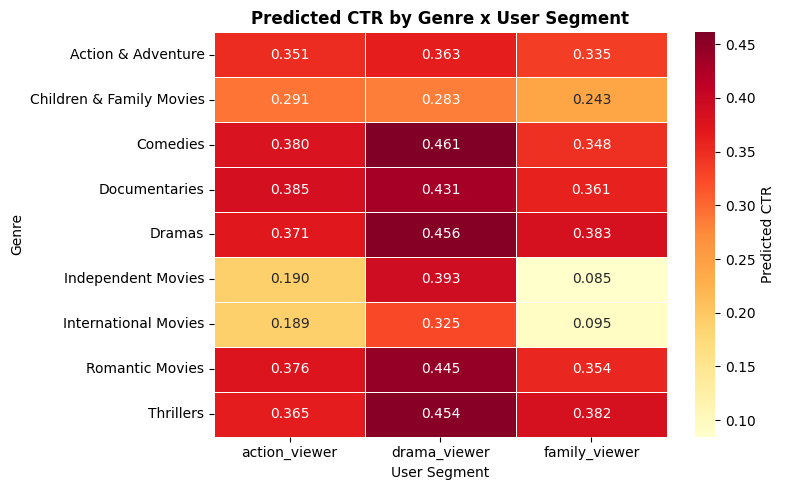

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Same title, different predicted CTR per user segment ===')
for title in ['Stranger Things','Bird Box','The Crown','Inception','Dark']:
    subset = df_predictions[df_predictions['title'] == title]
    if not subset.empty:
        print(f'\n{title}:')
        print(subset[['user_segment','genre_bucket','avg_aesthetic_score','predicted_ctr']].to_string(index=False))
        break

pivot = df_predictions.groupby(['genre_bucket','user_segment'])['predicted_ctr'].mean().unstack()
print('\n=== Avg predicted CTR by genre x segment ===')
print(pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Predicted CTR'})
ax.set_title('Predicted CTR by Genre x User Segment', fontweight='bold')
ax.set_xlabel('User Segment')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_predicted_ctr_heatmap.png'), bbox_inches='tight')
plt.show()

In [12]:
df_predictions.to_csv(os.path.join(OUTPUTS_DIR, 'netflix_ctr_predictions.csv'), index=False)

dashboard_summary = df_predictions.groupby(
    ['genre_bucket','user_segment'])['predicted_ctr'].mean().reset_index()
dashboard_summary.columns = ['genre','user_segment','avg_predicted_ctr']
dashboard_summary.to_csv(os.path.join(OUTPUTS_DIR, 'dashboard_summary.csv'), index=False)

best_per_title.to_csv(os.path.join(OUTPUTS_DIR, 'best_segment_per_title.csv'), index=False)

print('Files saved:')
print(f'  netflix_ctr_predictions.csv - {len(df_predictions):,} rows')
print(f'  dashboard_summary.csv       - {len(dashboard_summary):,} rows')
print(f'  best_segment_per_title.csv  - {len(best_per_title):,} rows')

Files saved:
  netflix_ctr_predictions.csv - 26,421 rows
  dashboard_summary.csv       - 27 rows
  best_segment_per_title.csv  - 8,807 rows


In [13]:
import joblib, json, tarfile

models_dir = os.path.join(REPO_ROOT, 'models')
os.makedirs(models_dir, exist_ok=True)

# 1. Save the trained XGBoost model
joblib.dump(xgb2, os.path.join(models_dir, 'xgb_ctr_model.pkl'))
print("Saved: models/xgb_ctr_model.pkl")

# 2. Save target-encoding maps (recomputed from training data — same as cell-train-model)
encoding_maps = {col: y.groupby(X[col]).mean().to_dict()
                 for col in ['product', 'campaign_id', 'webpage_id']}
encoding_maps['global_mean'] = float(global_mean)

with open(os.path.join(models_dir, 'encoding_maps.json'), 'w') as f:
    json.dump(encoding_maps, f, indent=2)
print("Saved: models/encoding_maps.json")

# 3. Package for SageMaker (model.pkl must be at top level of tar)
tar_path = os.path.join(models_dir, 'xgb_ctr_model.tar.gz')
with tarfile.open(tar_path, 'w:gz') as tar:
    tar.add(os.path.join(models_dir, 'xgb_ctr_model.pkl'), arcname='xgb_ctr_model.pkl')
print("Saved: models/xgb_ctr_model.tar.gz  <- upload this to S3")

Saved: models/xgb_ctr_model.pkl
Saved: models/encoding_maps.json
Saved: models/xgb_ctr_model.tar.gz  <- upload this to S3
